In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay

In [58]:
from google.colab import files
uploaded = files.upload()

Saving heart.csv to heart (1).csv


In [59]:
df = pd.read_csv('heart.csv')
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [60]:
df.shape

(920, 16)

In [61]:
df['num'] = df['num'].apply(lambda x : 1 if x>0 else 0)
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,1
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [62]:
x = df.drop('num',axis=1)
y = df['num']

In [63]:
print(df.isnull().sum())

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


In [64]:
df['num'].value_counts()

,count
num,
1,509
0,411


In [11]:
x = x.dropna()
x.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0


In [65]:
print(df["ca"].value_counts(dropna=False))
print(df["thal"].value_counts(dropna=False))
print(df["slope"].value_counts(dropna=False))

ca
NaN    611
0.0    181
1.0     67
2.0     41
3.0     20
Name: count, dtype: int64
thal
NaN                  486
normal               196
reversable defect    192
fixed defect          46
Name: count, dtype: int64
slope
flat           345
NaN            309
upsloping      203
downsloping     63
Name: count, dtype: int64


In [66]:
x['ca'] = x['ca'].replace(0,np.nan)
x['thal'] = x['thal'].replace(0,np.nan)
x['slope'] = x['slope'].replace(0,np.nan)

In [67]:
x  = x.drop('id',axis = 1)

In [13]:
x.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect
1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal
2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect
3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal
4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal


In [68]:
l = LabelEncoder()
x['sex'] = l.fit_transform(x['sex'])
x['fbs'] = l.fit_transform(x['fbs'])
x['exang'] = l.fit_transform(x['exang'])

In [69]:
x.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
0,63,1,Cleveland,typical angina,145.0,233.0,1,lv hypertrophy,150.0,0,2.3,downsloping,NaN,fixed defect
1,67,1,Cleveland,asymptomatic,160.0,286.0,0,lv hypertrophy,108.0,1,1.5,flat,3.0,normal
2,67,1,Cleveland,asymptomatic,120.0,229.0,0,lv hypertrophy,129.0,1,2.6,flat,2.0,reversable defect
3,37,1,Cleveland,non-anginal,130.0,250.0,0,normal,187.0,0,3.5,downsloping,NaN,normal
4,41,0,Cleveland,atypical angina,130.0,204.0,0,lv hypertrophy,172.0,0,1.4,upsloping,NaN,normal


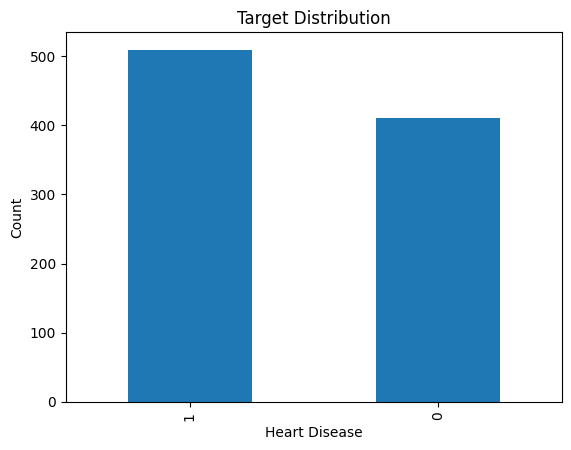

In [70]:
import matplotlib.pyplot as plt

y.value_counts().plot(kind="bar")

plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.title("Target Distribution")
plt.show()

In [71]:
print(df['dataset'].unique())
print(df['restecg'].unique())
print(df['thal'].unique())

['Cleveland' 'Hungary' 'Switzerland' 'VA Long Beach']
['lv hypertrophy' 'normal' 'st-t abnormality' nan]
['fixed defect' 'normal' 'reversable defect' nan]


In [72]:
x = df.drop('num', axis=1)
x = x.dropna()
x = x.drop('id', axis=1)

l = LabelEncoder()
x['sex'] = l.fit_transform(x['sex'])
x['fbs'] = l.fit_transform(x['fbs'])
x['exang'] = l.fit_transform(x['exang'])
x = x.drop('dataset', axis=1)
x['restecg'] = l.fit_transform(x['restecg'])
x['thal'] = l.fit_transform(x['thal'])

In [73]:
print(df['cp'].unique())
print(df['slope'].unique())

['typical angina' 'asymptomatic' 'non-anginal' 'atypical angina']
['downsloping' 'flat' 'upsloping' nan]


In [74]:
x['cp'] = l.fit_transform(x['cp'])
x['slope'] = l.fit_transform(x['slope'])
ss = StandardScaler()
x['cp'] = ss.fit_transform(x['cp'].values.reshape(-1,1))
x['slope'] = ss.fit_transform(x['slope'].values.reshape(-1,1))

In [75]:
x.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
0,63,1,1.987204,145.0,233.0,1,0,150.0,0,2.3,-2.264299,0.0,0
1,67,1,-0.920662,160.0,286.0,0,0,108.0,1,1.5,-0.640737,3.0,1
2,67,1,-0.920662,120.0,229.0,0,0,129.0,1,2.6,-0.640737,2.0,2
3,37,1,1.017915,130.0,250.0,0,1,187.0,0,3.5,-2.264299,0.0,1
4,41,0,0.048627,130.0,204.0,0,0,172.0,0,1.4,0.982825,0.0,1


In [76]:
x['age'] = ss.fit_transform(x['age'].values.reshape(-1,1))

In [77]:
x['ca'] = ss.fit_transform(x['ca'].values.reshape(-1,1))
x['thalach'] = ss.fit_transform(x['thalch'].values.reshape(-1,1))
x['trestbps'] = ss.fit_transform(x['trestbps'].values.reshape(-1,1))
x['chol'] = ss.fit_transform(x['chol'].values.reshape(-1,1))
x['oldpeak'] = ss.fit_transform(x['oldpeak'].values.reshape(-1,1))

In [78]:
x.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,thalach
0,0.940446,1,1.987204,0.749760,-0.262867,1,0,150.0,0,1.069475,-2.264299,-0.718306,0,0.029124
1,1.384143,1,-0.920662,1.596354,0.747722,0,0,108.0,1,0.380309,-0.640737,2.487269,1,-1.790447
2,1.384143,1,-0.920662,-0.661231,-0.339138,0,0,129.0,1,1.327912,-0.640737,1.418744,2,-0.880662
3,-1.943588,1,1.017915,-0.096835,0.061285,0,1,187.0,0,2.103224,-2.264299,-0.718306,1,1.632079
4,-1.499891,0,0.048627,-0.096835,-0.815830,0,0,172.0,0,0.294163,0.982825,-0.718306,1,0.982232


In [79]:
y = y.loc[x.index]
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [52]:
x_train.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,thalach
6,0.829521,0,-0.920662,0.467562,0.404503,0,0,160.0,0,2.189370,-2.264299,1.418744,1,0.462355
185,0.940446,0,0.048627,0.467562,-0.987440,0,1,179.0,0,-0.911877,0.982825,1.418744,1,1.285494
187,1.273219,1,0.048627,1.596354,-0.014986,0,1,120.0,1,-0.911877,-0.640737,2.487269,0,-1.270570
147,-1.499891,1,1.017915,-1.112748,0.061285,0,1,179.0,0,-0.911877,0.982825,-0.718306,1,1.285494
30,1.605992,0,1.987204,0.467562,-0.148460,0,1,151.0,0,0.638746,0.982825,1.418744,1,0.072447


In [84]:
rf = Pipeline([
    ('model',RandomForestClassifier(
        n_estimators=500,
        max_depth=8,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])
rf.fit(x_train,y_train)

Pipeline(steps=[('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=8,
                                        min_samples_leaf=2, n_estimators=500,
                                        n_jobs=-1, random_state=42))])

In [85]:
rf_pred = rf.predict(x_test)

In [86]:
rf.score(x_train,y_train)

0.9874476987447699

In [87]:
rf.score(x_test,y_test)

0.85

In [88]:
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       0.86      0.89      0.87        35
           1       0.83      0.80      0.82        25

    accuracy                           0.85        60
   macro avg       0.85      0.84      0.84        60
weighted avg       0.85      0.85      0.85        60



In [92]:
gbc = Pipeline([
    ('model',GradientBoostingClassifier(
        n_estimators=500,
        learning_rate = 0.05,
        max_depth = 2,
        random_state=42
    ))
])
gbc.fit(x_train,y_train)

Pipeline(steps=[('model',
                 GradientBoostingClassifier(learning_rate=0.05, max_depth=2,
                                            n_estimators=500,
                                            random_state=42))])

In [94]:
gbc.score(x_train,y_train)

0.99581589958159

In [95]:
gbc.score(x_test,y_test)

0.8333333333333334

In [96]:
print(classification_report(y_test,gbc.predict(x_test)))

              precision    recall  f1-score   support

           0       0.90      0.80      0.85        35
           1       0.76      0.88      0.81        25

    accuracy                           0.83        60
   macro avg       0.83      0.84      0.83        60
weighted avg       0.84      0.83      0.83        60



In [97]:
from xgboost import XGBClassifier

xgb = Pipeline([
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=2,
        random_state=42,
        eval_metric="logloss"
    ))
])
xgb.fit(x_train, y_train)

Pipeline(steps=[('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.8, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=True, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.03,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None, min_child_weight=3,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=300,
                               n_jobs=None, num_parallel_tree=None, ...))])

In [98]:
xgb.score(x_train,y_train)

0.9288702928870293

In [99]:
xgb.score(x_test,y_test)

0.8666666666666667

In [101]:
print(classification_report(y_test,xgb.predict(x_test)))

              precision    recall  f1-score   support

           0       0.89      0.89      0.89        35
           1       0.84      0.84      0.84        25

    accuracy                           0.87        60
   macro avg       0.86      0.86      0.86        60
weighted avg       0.87      0.87      0.87        60



In [103]:
svm = Pipeline([
    ('model',SVC(
        C=10,
        kernel='rbf',
        probability = True,
        random_state=42,
        class_weight = "balanced"
    ))
])
svm.fit(x_train,y_train)

Pipeline(steps=[('model',
                 SVC(C=10, class_weight='balanced', probability=True,
                     random_state=42))])

In [104]:
svm.score(x_train,y_train)

0.7238493723849372

In [105]:
svm.score(x_test,y_test)

0.7166666666666667

In [106]:
print(classification_report(y_test,svm.predict(x_test)))

              precision    recall  f1-score   support

           0       0.72      0.83      0.77        35
           1       0.70      0.56      0.62        25

    accuracy                           0.72        60
   macro avg       0.71      0.69      0.70        60
weighted avg       0.71      0.72      0.71        60



In [107]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
models = {
    "Random Forest": rf,
    "Gradient Boosting": gbc,
    "XGBoost": xgb,
    "SVM": svm
}
for name,model in models.items():
    y_pred = model.predict(x_test)
    print(name)
    print("Accuracy: {:.2f}".format(accuracy_score(y_test, y_pred)))
    print("Precision: {:.2f}".format(precision_score(y_test, y_pred)))
    print("Recall: {:.2f}".format(recall_score(y_test, y_pred)))
    print("F1 Score: {:.2f}".format(f1_score(y_test, y_pred)))
    print("ROC AUC Score: {:.2f}".format(roc_auc_score(y_test, y_pred)))
    print('-'*40)



Random Forest
Accuracy: 0.85
Precision: 0.83
Recall: 0.80
F1 Score: 0.82
ROC AUC Score: 0.84
----------------------------------------
Gradient Boosting
Accuracy: 0.83
Precision: 0.76
Recall: 0.88
F1 Score: 0.81
ROC AUC Score: 0.84
----------------------------------------
XGBoost
Accuracy: 0.87
Precision: 0.84
Recall: 0.84
F1 Score: 0.84
ROC AUC Score: 0.86
----------------------------------------
SVM
Accuracy: 0.72
Precision: 0.70
Recall: 0.56
F1 Score: 0.62
ROC AUC Score: 0.69
----------------------------------------


In [108]:
xgb = Pipeline([
    ("model", XGBClassifier(
        n_estimators=200,
        learning_rate=0.03,
        max_depth=2,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.2,
        reg_lambda=3.0,
        gamma=0.1,
        random_state=42,
        eval_metric="logloss"
    ))
])
xgb.fit(x_train, y_train)

Pipeline(steps=[('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.8, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=True, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=0.1, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.03,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=2, max_leaves=None, min_child_weight=5,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=200,
                               n_jobs=None, num_parallel_tree=None, ...))])

In [109]:
xgb.score(x_train,y_train)

0.8828451882845189

In [110]:
xgb.score(x_test,y_test)

0.85

In [111]:
print(classification_report(y_test,xgb.predict(x_test)))

              precision    recall  f1-score   support

           0       0.86      0.89      0.87        35
           1       0.83      0.80      0.82        25

    accuracy                           0.85        60
   macro avg       0.85      0.84      0.84        60
weighted avg       0.85      0.85      0.85        60



In [114]:
xgb_pred = xgb.predict(x_test)
print("XGBClassifier")
print("Accuracy: {:.2f}".format(accuracy_score(y_test, xgb_pred)))
print("Precision: {:.2f}".format(precision_score(y_test, xgb_pred)))
print("Recall: {:.2f}".format(recall_score(y_test, xgb_pred)))
print("F1 Score: {:.2f}".format(f1_score(y_test, xgb_pred)))
print("ROC AUC Score: {:.2f}".format(roc_auc_score(y_test, xgb_pred)))

XGBClassifier
Accuracy: 0.85
Precision: 0.83
Recall: 0.80
F1 Score: 0.82
ROC AUC Score: 0.84
